### **This project involves training a machine learning model to detect credit card fraud using the Credit Card Fraud Detection dataset from Kaggle. It utilizes Decision Trees algorithms and Ensemble methods to classify transactions as fraudulent or not. Finally, the various techniques are compared to determine the best performing model for this classification task.**

In [16]:
#imports
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.src.metrics.metrics_utils import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Download, explore and preprocess the data

In [2]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

#load and explore the dataset
data = pd.read_csv(path + "/creditcard.csv")
data.head()

Path to dataset files: C:\Users\chalo\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
#handle missing values
data = data.dropna()

In [4]:
#check for class imbalance
class_counts = data['Class'].value_counts()
print("Class distribution:\n", class_counts)

Class distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


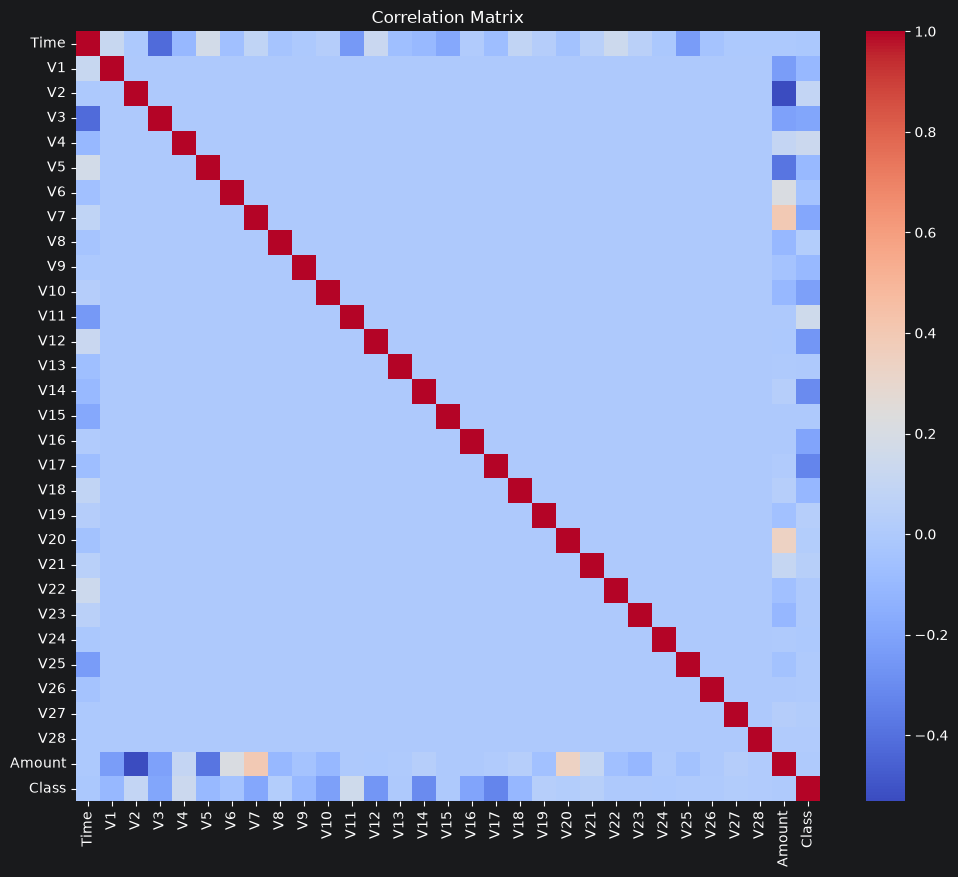

In [5]:
#visualize correlation between features
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [6]:
#drop irrelevant features
data = data.drop(['Time'], axis=1)

In [7]:
#split the data into features and target variable
X = data.drop('Class', axis=1)
y = data['Class']

#split the dataset into training and testing sets
(x_train, x_test, y_train, y_test) = train_test_split(X, y, test_size=0.2, random_state=117)

Implement Decision Tree Classifier

Confusion Matrix:
tf.Tensor(
[[56848    25]
 [   22    67]], shape=(2, 2), dtype=int32)
Accuracy: 0.9992
Precision: 0.7283
Recall: 0.7528
F1 Score: 0.7403


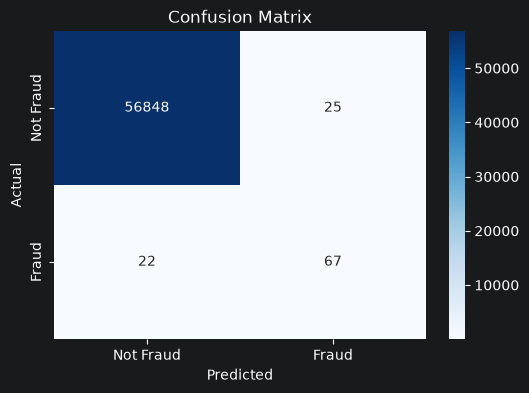

In [8]:
from keras.src.metrics.metrics_utils import confusion_matrix

#initialize and train the Decision Tree Classifier
model = DecisionTreeClassifier()
model.fit(x_train, y_train)

#test the model and evaluate its performance
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

#confusion matrix
cm = confusion_matrix(y_test, y_pred, num_classes=2)
print("Confusion Matrix:")
print(cm)

#plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

#print("Decision Tree Classifier Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Implement Random Forest Classifier (Bagging)

Confusion Matrix:
tf.Tensor(
[[56871     2]
 [   22    67]], shape=(2, 2), dtype=int32)
Accuracy: 0.9996
Precision: 0.9710
Recall: 0.7528
F1 Score: 0.8481


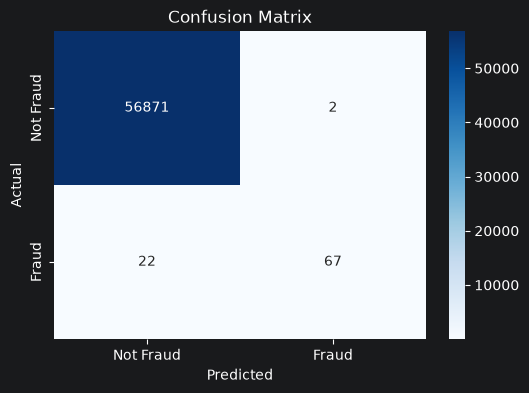

In [9]:
#initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=117)
rf_model.fit(x_train, y_train)

#test the model and evaluate its performance
y_pred_rf = rf_model.predict(x_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

#confusion matrix
cm = confusion_matrix(y_test, y_pred_rf, num_classes=2)
print("Confusion Matrix:")
print(cm)

#plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

#print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")

Implement AdaBoost Classifier (Boosting)

Confusion Matrix:
tf.Tensor(
[[56852    21]
 [   27    62]], shape=(2, 2), dtype=int32)
Accuracy: 0.9992
Precision: 0.7470
Recall: 0.6966
F1 Score: 0.7209


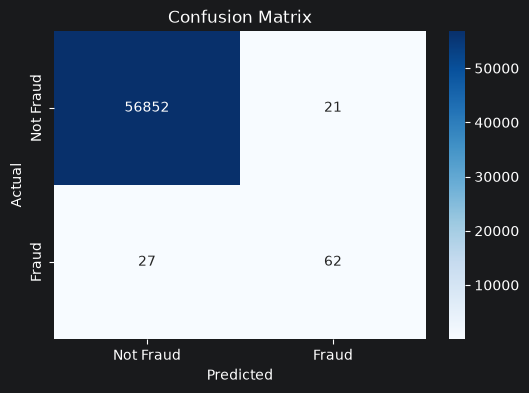

In [10]:
#initialize and train the AdaBoost Classifier
adaboost_model = AdaBoostClassifier(n_estimators=100, random_state=117)
adaboost_model.fit(x_train, y_train)

#test the model and evaluate its performance
y_pred_ab = adaboost_model.predict(x_test)
accuracy_ab = accuracy_score(y_test, y_pred_ab)
precision_ab = precision_score(y_test, y_pred_ab)
recall_ab = recall_score(y_test, y_pred_ab)
f1_ab = f1_score(y_test, y_pred_ab)

#confusion matrix
cm = confusion_matrix(y_test, y_pred_ab, num_classes=2)
print("Confusion Matrix:")
print(cm)

#plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

#print("AdaBoost Classifier Performance:")
print(f"Accuracy: {accuracy_ab:.4f}")
print(f"Precision: {precision_ab:.4f}")
print(f"Recall: {recall_ab:.4f}")
print(f"F1 Score: {f1_ab:.4f}")

Standardize the features

In [11]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

Implement Stacking Classifier (Ensemble of Bagging and Boosting)

Confusion Matrix:
tf.Tensor(
[[56849    24]
 [   23    66]], shape=(2, 2), dtype=int32)
Accuracy: 0.9992
Precision: 0.7333
Recall: 0.7416
F1 Score: 0.7374


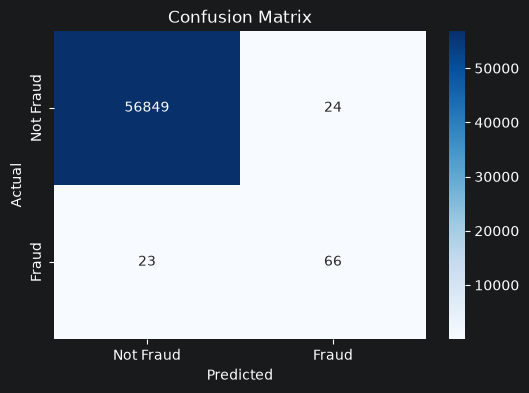

In [12]:
from sklearn.ensemble import StackingClassifier

#initialize and train the Stacking Classifier
estimators = [
    ('lr', LogisticRegression(random_state=117)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=117)),
    ('ab', AdaBoostClassifier(n_estimators=100, random_state=117))
]
stacking_model = StackingClassifier(estimators=estimators, final_estimator=DecisionTreeClassifier())
stacking_model.fit(x_train, y_train)

#test the model and evaluate its performance
y_pred_stack = stacking_model.predict(x_test)
accuracy_stack = accuracy_score(y_test, y_pred_stack)
precision_stack = precision_score(y_test, y_pred_stack)
recall_stack = recall_score(y_test, y_pred_stack)
f1_stack = f1_score(y_test, y_pred_stack)

#confusion matrix
cm = confusion_matrix(y_test, y_pred_stack, num_classes=2)
print("Confusion Matrix:")
print(cm)

#plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

#print("Stacking Classifier Performance:")
print(f"Accuracy: {accuracy_stack:.4f}")
print(f"Precision: {precision_stack:.4f}")
print(f"Recall: {recall_stack:.4f}")
print(f"F1 Score: {f1_stack:.4f}")


Table comparing the performance of all models (Decision Tree, RandomForestClassifier, AdaBoostClassifier, and StackingClassifier)

In [13]:
#create a performance comparison table
performance_data = {
    'Model': ['Decision Tree', 'Random Forest', 'AdaBoost', 'Stacking'],
    'Accuracy': [accuracy, accuracy_rf, accuracy_ab, accuracy_stack],
    'Precision': [precision, precision_rf, precision_ab, precision_stack],
    'Recall': [recall, recall_rf, recall_ab, recall_stack],
    'F1 Score': [f1, f1_rf, f1_ab, f1_stack]
}
performance_df = pd.DataFrame(performance_data)
performance_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.999175,0.728261,0.752809,0.740331
1,Random Forest,0.999579,0.971014,0.752809,0.848101
2,AdaBoost,0.999157,0.746988,0.696629,0.720930
3,Stacking,0.999175,0.733333,0.741573,0.737430
